# Comparación de modelos de machine learning para la predicción de cáncer de pulmón

## Importación de librerías y modelos

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Librerías importadas correctamente")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


## Proceso ETL y visualizaciones

### Carga de Dataset

In [2]:
DATA_PATH = "data/dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Datos: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Datos: 460292 filas y 25 columnas


,Country,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Rural_or_Urban,Socioeconomic_Status,Healthcare_Access,...,Treatment_Access,Clinical_Trial_Access,Language_Barrier,Mortality_Risk,5_Year_Survival_Probability,Delay_in_Diagnosis,Family_History,Indoor_Smoke_Exposure,Tobacco_Marketing_Exposure,Final_Prediction
0,Russia,82,Male,Former Smoker,Yes,Medium,No,Urban,High,Limited,...,Partial,Yes,No,0.263278,0.797576,Yes,No,No,No,No
1,Thailand,66,Female,Former Smoker,No,High,No,Rural,Middle,Good,...,Partial,Yes,No,0.154697,0.336674,Yes,No,No,Yes,No
2,Colombia,87,Male,Former Smoker,No,Medium,No,Urban,Low,Poor,...,Partial,Yes,No,0.607435,0.063621,No,No,No,Yes,No
3,Egypt,51,Female,Former Smoker,No,Low,Yes,Rural,High,Good,...,Full,No,No,0.081184,0.336814,No,No,No,Yes,No
4,DR Congo,43,Male,Former Smoker,No,High,No,Urban,Middle,Good,...,Full,No,No,0.643276,0.820103,No,No,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460292 entries, 0 to 460291
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      460292 non-null  object 
 1   Age                          460292 non-null  int64  
 2   Gender                       460292 non-null  object 
 3   Smoking_Status               460292 non-null  object 
 4   Second_Hand_Smoke            460292 non-null  object 
 5   Air_Pollution_Exposure       460292 non-null  object 
 6   Occupation_Exposure          460292 non-null  object 
 7   Rural_or_Urban               460292 non-null  object 
 8   Socioeconomic_Status         460292 non-null  object 
 9   Healthcare_Access            460292 non-null  object 
 10  Insurance_Coverage           460292 non-null  object 
 11  Screening_Availability       460292 non-null  object 
 12  Stage_at_Diagnosis           460292 non-null  object 
 13 

### Variable objetivo

In [4]:
target = 'Final_Prediction'
df[target] = df[target].map({'Yes':1, 'No':0})

### Eliminación de valores nulos

In [5]:
# Rellenar nulos con la moda
if 'Treatment_Access' in df.columns:
    mode_val = df['Treatment_Access'].mode()[0]
    df['Treatment_Access'] = df['Treatment_Access'].fillna(mode_val)

# Rellenar nulos con Unkmown
if 'Mutation_Type' in df.columns:
    df['Mutation_Type'] = df['Mutation_Type'].fillna('Unknown')

### Mapeo para variables ordinales

In [6]:
ordinal_mappings = {
    'Smoking_Status': {'Non-Smoker': 0, 'Former Smoker': 1, 'Smoker': 2},
    'Air_Pollution_Exposure': {'Low': 0, 'Medium': 1, 'High': 2},
    'Socioeconomic_Status': {'Low': 0, 'Middle': 1, 'High': 2},
    'Healthcare_Access': {'Poor': 0, 'Limited': 1, 'Good': 2},
    'Stage_at_Diagnosis': {'I': 1, 'II': 2, 'III': 3, 'IV': 4},
    'Treatment_Access': {'None': 0, 'Partial': 1, 'Full': 2}
}

# Aplicar mapeo
for col, mapping in ordinal_mappings.items():
  if col in df.columns:
    df[col] = df[col].map(mapping)

### Mapeo para variables binarias

In [7]:
binary_cols = ['Second_Hand_Smoke', 'Occupation_Exposure', 'Insurance_Coverage',
               'Screening_Availability', 'Clinical_Trial_Access', 'Language_Barrier',
               'Delay_in_Diagnosis', 'Family_History', 'Indoor_Smoke_Exposure',
               'Tobacco_Marketing_Exposure', 'Gender']

# Mapeo
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
  if col in df.columns:
    df[col] = df[col].map(binary_map)

### Columnas numéricas continuas (escalar) y nominales restantes (one-hot)

In [8]:
# Columnas numéricas continuas
numeric_cols = ['Age', 'Mortality_Risk', '5_Year_Survival_Probability']
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Columnas nominales restantes
already_handled = set(ordinal_mappings.keys()) | set(binary_cols) | set(numeric_cols) | {target} # Escluir las anteriores
categorical_nominal = [col for col in df.columns if col not in already_handled]

# One-hot
df = pd.get_dummies(df, columns=categorical_nominal, drop_first=True)

df.head()

,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Socioeconomic_Status,Healthcare_Access,Insurance_Coverage,Screening_Availability,...,Country_Thailand,Country_Turkey,Country_UK,Country_USA,Country_Vietnam,Rural_or_Urban_Urban,Cancer_Type_SCLC,Mutation_Type_EGFR,Mutation_Type_KRAS,Mutation_Type_Unknown
0,82,1,1,1,1,0,2,1,1,1,...,False,False,False,False,False,True,False,True,False,False
1,66,0,1,0,2,0,1,2,0,0,...,True,False,False,False,False,False,False,True,False,False
2,87,1,1,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
3,51,0,1,0,0,1,2,2,0,0,...,False,False,False,False,False,False,False,True,False,False
4,43,1,1,0,2,0,1,2,1,0,...,False,False,False,False,False,True,False,False,False,True


### Convertir variables booleanas a enteros

In [9]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

### Verificación final

In [10]:
print(f"Total de nulos en el dataset: {df.isnull().sum().sum()}")

Total de nulos en el dataset: 0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460292 entries, 0 to 460291
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          460292 non-null  int64  
 1   Gender                       460292 non-null  int64  
 2   Smoking_Status               460292 non-null  int64  
 3   Second_Hand_Smoke            460292 non-null  int64  
 4   Air_Pollution_Exposure       460292 non-null  int64  
 5   Occupation_Exposure          460292 non-null  int64  
 6   Socioeconomic_Status         460292 non-null  int64  
 7   Healthcare_Access            460292 non-null  int64  
 8   Insurance_Coverage           460292 non-null  int64  
 9   Screening_Availability       460292 non-null  int64  
 10  Stage_at_Diagnosis           460292 non-null  int64  
 11  Treatment_Access             460292 non-null  int64  
 12  Clinical_Trial_Access        460292 non-null  int64  
 13 

In [12]:
df.describe()

,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Socioeconomic_Status,Healthcare_Access,Insurance_Coverage,Screening_Availability,...,Country_Thailand,Country_Turkey,Country_UK,Country_USA,Country_Vietnam,Rural_or_Urban_Urban,Cancer_Type_SCLC,Mutation_Type_EGFR,Mutation_Type_KRAS,Mutation_Type_Unknown
count,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,...,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000,460292.000000
mean,60.044183,0.500574,1.000463,0.300257,0.798109,0.250065,0.900400,1.299703,0.701409,0.600306,...,0.033674,0.033444,0.033305,0.033342,0.033335,0.699964,0.150585,0.299903,0.200108,0.300186
std,17.590029,0.500000,0.817074,0.458370,0.747899,0.433051,0.699941,0.781555,0.457640,0.489836,...,0.180390,0.179793,0.179432,0.179528,0.179511,0.458274,0.357644,0.458216,0.400081,0.458339
min,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,60.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,75.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,90.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Correlación con variable objetivo
No existe una correlación fuerte en ninguna variable

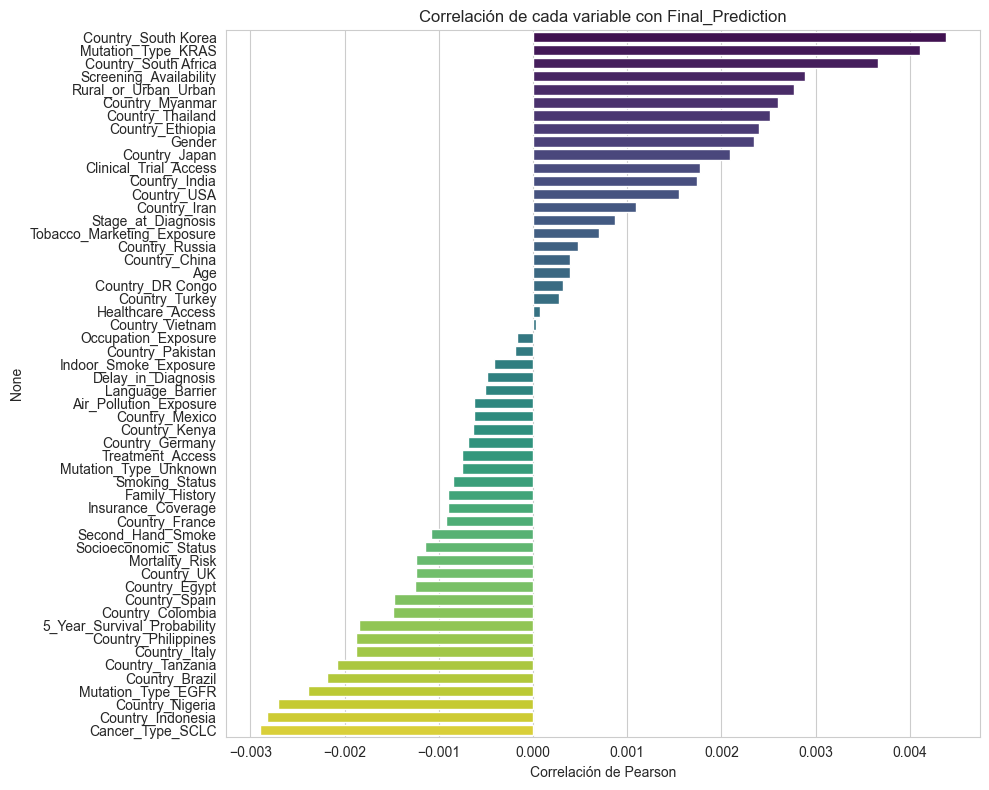

In [13]:
# Calcular correlación con el objetivo y ordenar
corr_target = df.corr()['Final_Prediction'].drop('Final_Prediction').sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title('Correlación de cada variable con Final_Prediction')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

### Heatmap con 15 variables más correlacionadas

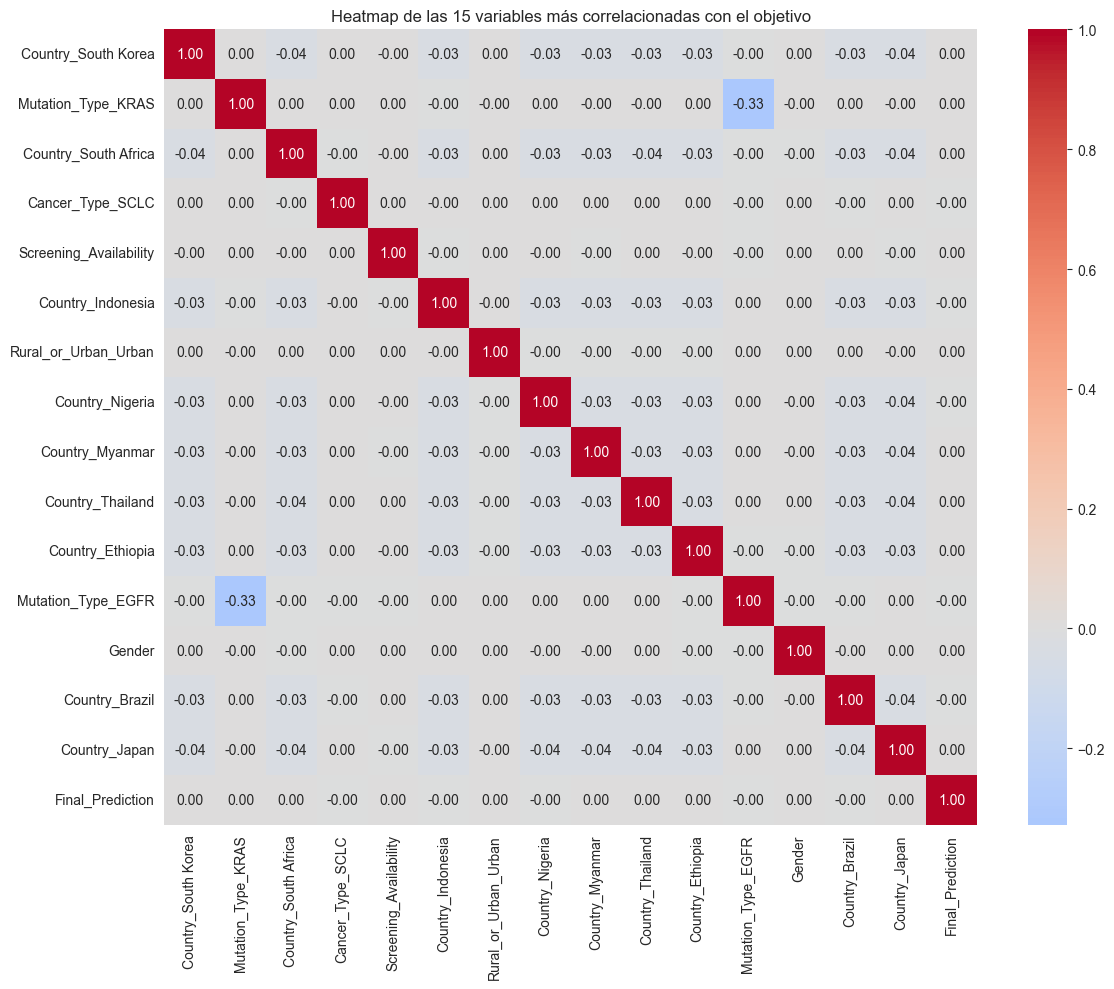

In [14]:
top_vars = corr_target.abs().nlargest(15).index.tolist() + ['Final_Prediction']
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_vars].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap de las 15 variables más correlacionadas con el objetivo')
plt.tight_layout()
plt.show()

## Entrenamiento de modelos predictivos

### División entrenamiento/prueba

In [15]:
X = df.drop(target, axis=1) # Características
y = df[target]              # Variable objetivo

# Entrenamiento/prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Distribución de la variable objetivo
print("Distribución de Final_Prediction:")
print(y.value_counts(normalize=True))

print("\nTop 5 correlaciones con el objetivo:")
corrs = X.corrwith(y).abs().sort_values(ascending=False)
print(corrs.head())


Distribución de Final_Prediction:
Final_Prediction
0    0.799725
1    0.200275
Name: proportion, dtype: float64

Top 5 correlaciones con el objetivo:
Country_South Korea       0.004381
Mutation_Type_KRAS        0.004112
Country_South Africa      0.003664
Cancer_Type_SCLC          0.002894
Screening_Availability    0.002890
dtype: float64


### Escalado y Oversampling

In [ ]:
# Escalado de columnas numéricas (valores 0 a 1)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# Escalar columnas numéricas identificadas
for col in numeric_cols:
  if col in X_train.columns:
    X_train_scaled[col] = scaler.fit_transform(X_train[[col]]) # Calcula parámetros necesarios y transforma en esos mismos datos. Solo se usa en X_train
    X_test_scaled[col] = scaler.transform(X_test[[col]])       # Utiliza parámetros ya calculados. Solo se usa en X_test

# Aumento de datos con SMOTE al conjunto de entrenamiento (oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Tamaño original de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño alterado con SMOTE de entrenamiento: {X_train_resampled.shape[0]}")

### Optimización de muestreo (40k estratificados)

In [ ]:
SAMPLE_SIZE = 40000 # Tamaño balanceado para buscar hiperparámetros
X_sample, y_sample = resample(X_train_resampled, y_train_resampled,
                              n_samples=SAMPLE_SIZE, stratify=y_train_resampled,
                              random_state=42)

print(f"Tamaño muestra para optimización: {X_sample.shape[0]}")

# Validación cruzada estratificada (realizar 2 entrenamientos y validar con 1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Definición de modelos

In [ ]:
# Diccionario que guarda el modelo de ML y los hiperparámetros a probar de cada modelo

models_params = {
  'LogisticRegression': {
    'model': LogisticRegression(max_iter=1000, random_state=42),
    'params': {
      'C': [0.01, 0.1, 1, 10], 
      'penalty': ['l2'],
      'solver': ['lbfgs']
    }
  },
  'RandomForest': {
    'model': RandomForestClassifier(random_state=42),
    'params': {
      'n_estimators': [100, 200],
      'max_depth': [10, 20],
      'min_samples_split': [2, 5],
      'min_samples_leaf': [1, 2]
    }
  },
  'SVM_Lineal': { 
    'model': LinearSVC(random_state=42, dual = 'auto', max_iter=2000),
    'params': {
      'C': [0.01, 0.1, 1, 10],
      'loss': ['hinge', 'squared_hinge'],
      'penalty': ['l2']
    }
  },
  'KNN': {
    'model': KNeighborsClassifier(),
    'params': {
      'n_neighbors': [5, 7, 9],
      'weights': ['uniform', 'distance'],
      'p': [1, 2]
    }
  },
  'GradientBoosting': {
    'model': GradientBoostingClassifier(random_state=42),
    'params': {
      'n_estimators': [100, 200],
      'learning_rate': [0.01, 0.05],
      'max_depth': [3, 5],
      'subsample': [0.8, 1.0]
    }
  },
  'CatBoost': {
    'model': CatBoostClassifier(verbose=0, random_state=42),
    'params': {
      'iterations': [100, 200],
      'depth': [4, 6],
      'learning_rate': [0.01, 0.05],
      'l2_leaf_reg': [1, 3]
    }
  }
}

### Optimización de XGBoost con Optuna

In [ ]:
best_models = {}

def objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 50, 200),    
    'max_depth': trial.suggest_int('max_depth', 3, 8),
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    'gamma': trial.suggest_float('gamma', 0, 3),
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False
  }
  model = XGBClassifier(**params)
  # Validación cruzada manual para AUC
  auc_scores = []
  for train_idx, val_idx in cv.split(X_sample, y_sample):
    X_tr, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
    y_tr, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, y_proba))
  return np.mean(auc_scores)


print("\nOptimizando XGBoost con Optuna...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=35, show_progress_bar=True)
best_xgb_params = study.best_params
print("Mejores hiperparámetros para XGBoost:", best_xgb_params)

# Entrenar XGBoost final con todos los datos
xgb_best = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss',use_label_enconder=False)
xgb_best.fit(X_train_resampled, y_train_resampled)
best_models['XGBoost'] = xgb_best

### Optimización de los otros modelos con RandomizedSearchCV

In [ ]:

# Optimización del resto de modelos con RandomizedSearchCV
for name, mp in models_params.items():
  print(f"\nOptimizando {name} con RandomizedSearchCV...")
  model = mp['model'] 
  param_dist = mp['params']
  random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=12,
    cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
  )
  random_search.fit(X_sample, y_sample)
  print(f"Mejores parámetros para {name}: {random_search.best_params_}")
  # Entrenar modelo final con todos los datos
  final_model = random_search.best_estimator_
  final_model.fit(X_train_resampled, y_train_resampled)
  best_models[name] = final_model
  

### Evaluación en test

In [ ]:
# Función para evaluar un modelo ya entrenado en test
def evaluate_model(model, X_test, y_test, model_name):
  y_pred = model.predict(X_test)
  # LinearSVC no tiene predict_proba
  try:
    y_proba = model.predict_proba(X_test)[:, 1]
  except AttributeError:
    y_proba = model.decision_function(X_test)
  metrics = {
    'Model': model_name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_proba)
  }
  return metrics

results = []

for name, model in best_models.items():
  metrics = evaluate_model(model, X_test_scaled, y_test, name)
  results.append(metrics)

results_df = pd.DataFrame(results).set_index('Model')
print("\nResultados finales:\n", results_df.round(4))
results_df.to_csv('resultados_modelos.csv')

In [ ]:
print(df[target].value_counts(normalize=True))

### Gráfico de barras comparativo

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparación de métricas de los modelos')
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacion_modelos.png')
plt.show()

### Matrices de confusión para cada modelo

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()
for idx, (name, model) in enumerate(best_models.items()):
  y_pred = model.predict(X_test_scaled)
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
  axes[idx].set_title(f'{name}\nMatriz de confusión')
  axes[idx].set_xlabel('Predicho')
  axes[idx].set_ylabel('Real')

# Ocultar último subplot
if len(best_models) < 8:
  axes[-1].axis('off')
plt.tight_layout()
plt.savefig('matrices_confusion.png')
plt.show()

### Curva ROC para cada modelo

In [ ]:
plt.figure(figsize=(10,8))
for name, model in best_models.items():
  y_proba = model.predict_proba(X_test_scaled)[:, 1]
  fpr, tpr, _ = roc_curve(y_test, y_proba)
  auc = roc_auc_score(y_test, y_proba)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('curvas_roc.png')
plt.show()

## Seleción del mejor modelo

In [ ]:
results_df